## Archival publication note

This copy preserves the submitted calculations and historical outputs. Local paths were made relative for publication. Read [README](README.md) and [AUDIT](../../AUDIT.md) before interpreting results. Edited original cell indices: [0]. No fresh execution is claimed.


# Introduction to Machine Learning
### Practical Homework 2
#### Sharif Uni. of Tech. - EE Dep. - 1404-2 Semester
#### Deadline: 1405-02-26


**Note**: 
- You are allowed, and also suggested, to use Numpy, Pandas, Scikit, and Matplotlib libraries, UNLESS IT IS EXPLICITLY ADVISED OTHERWISE. <br>
- Load all the dependecies of a cell inside itself, do not create inter-cell dependence for files, libraries and variables

**TA Contact info:**
- Bale: @firoozi_emad <br>
- Sharif email: emad.firoozi77@sharif.edu
- Gmail: emad.firoozi84@gmail.com

# Problem 1: Escaping Saddle Points (First-Order vs. Second-Order Methods) - 25 points

In optimization, critical points where the gradient is zero ($\nabla \mathcal{L}(\theta) = 0$) are not always local minima. They can also be local maxima or saddle points. In high-dimensional non-convex landscapes, saddle points are exponentially more common than local minima and pose a significant challenge for optimization algorithms.

In this problem, we will analyze a 2D non-convex objective function characterized by a pathological saddle point. You will implement standard Gradient Descent (GD), Momentum-based GD, and Newton's Method entirely from scratch using PyTorch's autodiff capabilities to understand how different order methods navigate this curvature.

## 1.1 The Objective Function

Consider the following loss function:
$$ \mathcal{L}(\theta_1, \theta_2) = \theta_1^2 - 2\theta_2^2 + 0.5\theta_2^4 $$

**Task:**
1. Analytically derive the gradient vector $\nabla \mathcal{L}$ and the Hessian matrix $H$. (Do this on paper; you will use this knowledge to debug your code).
2. Implement this function in PyTorch in the cell below. Your function must be able to process a batched grid of inputs for contour plotting, as well as a single `torch.Tensor` parameter vector for optimization.

In [50]:
import torch
import numpy as np
import matplotlib.pyplot as plt

def loss_function(theta):

    # here i used ellipsis '...' to handle both batched and unbatched inputs
    theta_1 = theta[..., 0]
    theta_2 = theta[..., 1]

    loss = (theta_1 ** 2) - (2 * theta_2 ** 2) + (0.5 * theta_2 ** 4)
    return loss


## 1.2 Implementing First-Order Methods from Scratch

First-order methods rely solely on the gradient of the objective function. 
* **Standard GD:** Updates parameters purely based on the steepest descent direction.
  $$ \theta_{t+1} = \theta_t - \eta \nabla \mathcal{L}(\theta_t) $$
* **Momentum GD:** Accumulates a velocity vector to power through narrow valleys and escape flat regions.
  $$ m_t = \beta m_{t-1} + \nabla \mathcal{L}(\theta_t) $$
  $$ \theta_{t+1} = \theta_t - \eta m_t $$

**Task:** 
Implement both GD and Momentum in the function below. You **may not** use `torch.optim`. You must use `torch.autograd.grad` or `.backward()` to compute the gradients dynamically at each step. Ensure you detach tensors or use `torch.no_grad()` appropriately when performing the parameter updates so you do not build an infinite computational graph.

In [51]:
import torch

def optimize_first_order(init_theta, method='gd', lr=0.01, momentum_beta=0.9, steps=100):
    theta = init_theta.clone().detach().requires_grad_(True)
    trajectory = [theta.detach().clone()]
    velocity = torch.zeros_like(theta)

    for t in range(steps):
        # 1. as asked , here we compute loss and gradient
        loss = loss_function(theta)
        loss.backward() # this would compute the gradient and stores it in theta.grad

        with torch.no_grad():
            # 2. parameter update
            if method == 'gd':

                theta -= lr * theta.grad
            elif method == 'momentum':

                velocity = momentum_beta * velocity + theta.grad
                theta -= lr * velocity
            else:
                raise ValueError("Method must be 'gd' or 'momentum'")

        # 3. this would clear gradients for the next step so they don't accumulate
        theta.grad.zero_()

        trajectory.append(theta.detach().clone())

    return torch.stack(trajectory)


## 1.3 Implementing Second-Order Methods (Newton's Method)

Newton's method leverages the second-order Taylor expansion to account for the curvature of the loss landscape, utilizing the inverse of the Hessian matrix $H$.
$$ \theta_{t+1} = \theta_t - \eta H^{-1} \nabla \mathcal{L}(\theta_t) $$

*Note: We include a step size $\eta$ (often called Damped Newton's Method) to prevent drastic jumps early in optimization.*

**Task:**
Computing the Hessian in modern deep learning is computationally prohibitive, but trivial for a 2D problem. Use `torch.autograd.functional.hessian` (or compute the Jacobian of the gradient manually) to implement Newton's Method.

In [52]:
import torch

def optimize_newton(init_theta, lr=0.1, steps=100):
    theta = init_theta.clone().detach().requires_grad_(True)
    trajectory = [theta.detach().clone()]


    eval_loss = lambda x: loss_function(x)

    for t in range(steps):
        # 1 gradient
        loss = loss_function(theta)
        loss.backward()
        grad = theta.grad

        # 2. hessian
        H = torch.autograd.functional.hessian(eval_loss, theta)

        with torch.no_grad():
            # 3 newton step
            step = torch.linalg.solve(H, grad)

            # updated theta
            theta -= lr * step

        # 4. again we clear gradients for the next iteration
        theta.grad.zero_()

        trajectory.append(theta.detach().clone())

    return torch.stack(trajectory)


## 1.4 Execution & Visualization

It is time to test your algorithms. 
The origin $(0,0)$ is a strict saddle point for our function. If we initialize exactly at zero, the gradients will be zero, and the optimizer will not move. Therefore, we will initialize **very close** to the saddle point, adding a tiny perturbation: $\theta_{init} = (0.01, 0.01)$.

**Task:**
1. Run all three optimizers for `150` steps.
   * `lr=0.01` for GD.
   * `lr=0.01`, `beta=0.9` for Momentum.
   * `lr=0.1` for Newton's Method.
2. Complete the plotting code to overlay the trajectories on a 2D contour map of the loss landscape.

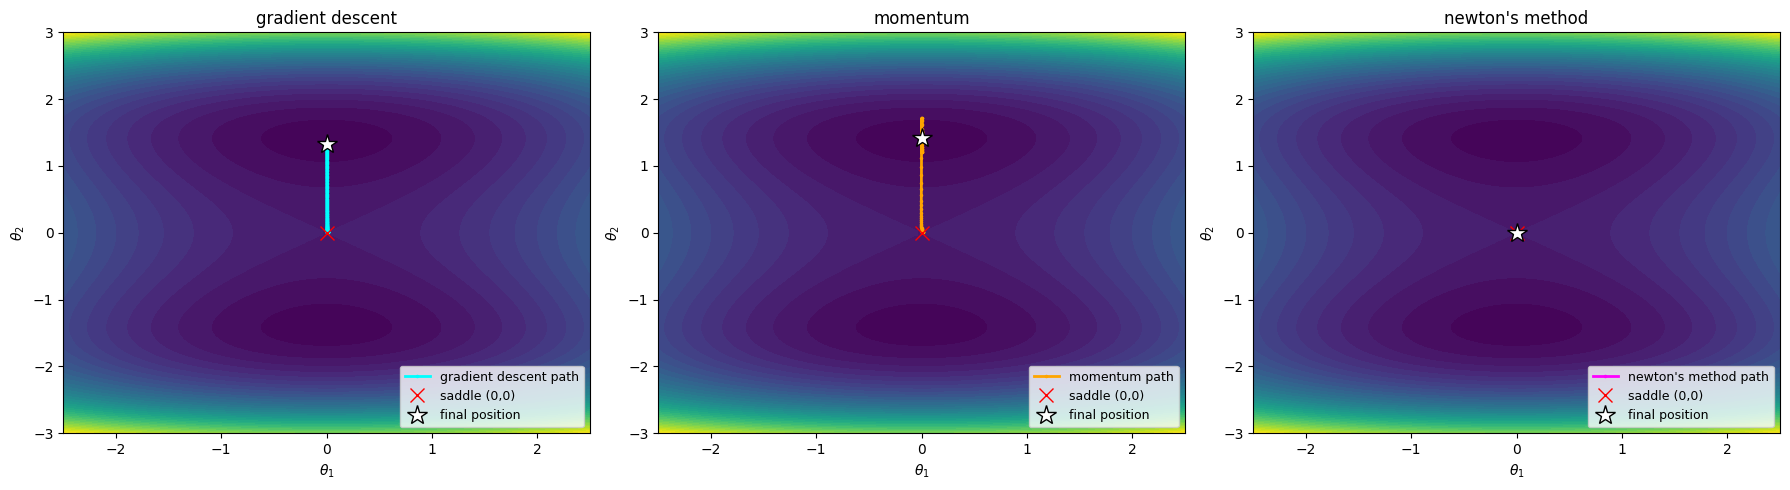

gd:       θ = (0.000483, 1.326162), loss = -1.970888
momentum: θ = (0.000002, 1.415245), loss = -1.999996
newton:   θ = (0.000000, 0.000000), loss = -0.000000


In [53]:
import torch
import matplotlib.pyplot as plt

init_theta = torch.tensor([0.01, 0.01])
steps = 150

traj_gd = optimize_first_order(init_theta, method='gd', lr=0.01, steps=steps)
traj_momentum = optimize_first_order(init_theta, method='momentum', lr=0.01, momentum_beta=0.9, steps=steps)
traj_newton = optimize_newton(init_theta, lr=0.1, steps=steps)

grid_x, grid_y = torch.meshgrid(torch.linspace(-2.5, 2.5, 100), torch.linspace(-3, 3, 100), indexing='ij')
grid_theta = torch.stack([grid_x.flatten(), grid_y.flatten()], dim=1)
grid_z = loss_function(grid_theta).reshape(100, 100)

fig, axes = plt.subplots(1, 3, figsize=(18, 5))

methods = [
    ('gradient descent', traj_gd, 'cyan'),
    ('momentum', traj_momentum, 'orange'),
    ("newton's method", traj_newton, 'magenta')
]

for ax, (title, traj, color) in zip(axes, methods):
    traj_np = traj.numpy()
    x = grid_x.numpy()
    y = grid_y.numpy()
    z = grid_z.numpy()

    ax.contourf(x, y, z, levels=50, cmap='viridis')

    ax.plot(traj_np[:, 0], traj_np[:, 1], color=color, marker='.', markersize=3,
            linestyle='-', linewidth=2, label=f'{title} path')

    ax.plot(0, 0, marker='x', color='red', markersize=10, linestyle='none', label='saddle (0,0)')

    ax.plot(traj_np[-1, 0], traj_np[-1, 1], marker='*', color='white', markeredgecolor='black',
            markersize=15, linestyle='none', label='final position')

    ax.set_title(title)
    ax.set_xlabel(r'$\theta_1$')
    ax.set_ylabel(r'$\theta_2$')
    ax.set_xlim([-2.5, 2.5])
    ax.set_ylim([-3, 3])
    ax.legend(loc='lower right', fontsize=9)

plt.tight_layout()
plt.show()

print(f"gd:       θ = ({traj_gd[-1][0]:.6f}, {traj_gd[-1][1]:.6f}), loss = {loss_function(traj_gd[-1]):.6f}")
print(f"momentum: θ = ({traj_momentum[-1][0]:.6f}, {traj_momentum[-1][1]:.6f}), loss = {loss_function(traj_momentum[-1]):.6f}")
print(f"newton:   θ = ({traj_newton[-1][0]:.6f}, {traj_newton[-1][1]:.6f}), loss = {loss_function(traj_newton[-1]):.6f}")


## 1.5 Analytical Questions

Based on your mathematical derivations and the observed trajectories in the plot above, answer the following questions:

**Question 1:** Analyze the trajectory of Vanilla GD vs. Momentum. Why does vanilla Gradient Descent struggle to escape the saddle point efficiently, and mathematically, how does the momentum term $\beta m_{t-1}$ alter the gradient vector to accelerate the escape?

**answer 1:**
vanilla Gradient descent struggles near the saddle point because the gradient approaches zero , resulting in exponentially smaller steps that cause stagnation. The momentum term $\beta m_{t-1}$ acts as velocity by accumulating historical gradients . Even when the current gradient is small, this accumulated history continues to drive the optimizer forward  , allowing it to accelerate past the flat region along the axis of negative curvature.

**Question 2:** Observe the trajectory of Newton's Method. You should notice that it behaves very strangely (and likely moves in the completely wrong direction) when initialized near this specific saddle point. 
Evaluate the Hessian matrix exactly at the point $(0,0)$. Is it positive-definite, negative-definite, or indefinite? Based on its eigenvalues, explain *why* Newton's method fails to minimize the function in this region and instead gets attracted to a local maximum along one of the axes. 

**answer 2:**
hessian evaluated at $(0,0)$ is $H = \begin{bmatrix} 2 & 0 \\ 0 & -4 \end{bmatrix}$. Its eigenvalues are $2$ and $-4$, making the matrix indefinite . Newton's step is defined as $\Delta \theta = -H^{-1}\nabla \mathcal{L}$. Because the eigenvalue corresponding to the $\theta_2$ axis is negative  , multiplying the gradient by the inverse Hessian flips the sign of the descent direction . Consequently , instead of stepping down to minimize the loss , Newton's method steps up the slope along the $\theta_2$ axis, getting attracted back toward the saddle point rather than escaping it.




# Problem 2: Implementing the Armijo-Goldstein Line Search - 25 points

In standard Gradient Descent, choosing a constant step size (learning rate $\eta$) is notoriously difficult. If $\eta$ is too large, the optimizer will overshoot the minimum and diverge; if it is too small, convergence takes an excruciatingly long time. 

To solve this, we use **Line Search** algorithms to dynamically compute the optimal step size at every iteration. In this problem, you will implement the **Armijo-Goldstein Backtracking Line Search** and test it on a notoriously difficult landscape: a poorly scaled (ill-conditioned) quadratic function.

## 2.1 The Mathematics of Armijo-Goldstein

Recall from the lecture slides that the sequence of step sizes $\{\eta_t\}$ can be determined dynamically. 
Let $d_t$ be our descent direction (for standard GD, $d_t = -g_t = -\nabla \mathcal{L}(\theta_t)$). 
Let $m = \langle \nabla \mathcal{L}(\theta_t), d_t \rangle$.

We choose an initial large learning rate $\eta_0$, a control parameter $c \in (0,1)$, and a decay factor $\tau \in (0,1)$. We then repeatedly decay the learning rate ($\eta \leftarrow \tau \eta$) until the following condition is met:

$$ \mathcal{L}(\theta_t + \eta d_t) \leq \mathcal{L}(\theta_t) + c \eta m $$

**Task:**
Familiarize yourself with this condition. Notice that because $d_t$ is a descent direction, $m$ is negative. This inequality ensures we achieve a *sufficient decrease* in the loss function relative to the step size we are taking.

## 2.2 The Ill-Conditioned Landscape

To demonstrate why line search is necessary, we will optimize an extremely "stretched" or ill-conditioned quadratic function. 

$$ \mathcal{L}(\theta) = \frac{1}{2} \theta^T Q \theta $$

where $Q = \begin{bmatrix} 100 & 0 \\ 0 & 1 \end{bmatrix}$. 

**Task:** Implement this loss function below.

In [54]:
import torch
import numpy as np
import matplotlib.pyplot as plt

def ill_conditioned_loss(theta):
    # q matrix
    Q = torch.tensor([[100.0, 0.0], [0.0, 1.0]])
    # compute L
    return 0.5 * theta @ Q @ theta

## 2.3 Implementing the Armijo-Goldstein Optimizer

You will now write a custom optimization loop. At every epoch, instead of taking a step with a fixed learning rate, you must compute the search direction, execute the backtracking `while` loop until the Armijo condition is satisfied, and *then* update the parameters.

**Task:**
Complete the `optimize_armijo` function. 

*Hint: Evaluating $\mathcal{L}(\theta_t + \eta d_t)$ requires calculating the loss at a hypothetical new position. Do this without breaking your PyTorch computation graph, or use `.detach()` appropriately so you do not accumulate massive memory overhead during the `while` loop.*

In [55]:
def optimize_armijo(init_theta, max_steps=100, eta_init=1.0, c=0.1, tau=0.5):
    theta = init_theta.clone().detach().requires_grad_(True)
    trajectory = [theta.detach().clone()]
    losses = []
    total_evals = 0

    for t in range(max_steps):
        loss = ill_conditioned_loss(theta)
        losses.append(loss.item())
        total_evals += 1

        # here we compute gradient and then set descent direction d_t = -grad
        loss.backward()
        grad = theta.grad.detach().clone()
        d_t = -grad

        with torch.no_grad():
            # this would detemine the slope
            m = torch.dot(grad, d_t).item()
            eta = eta_init

            # backtracking
            while True:
                theta_new = theta + eta * d_t
                loss_new = ill_conditioned_loss(theta_new).item()
                total_evals += 1
                # check sufficient decrease condition
                if loss_new <= loss.item() + c * eta * m:
                    break
                eta *= tau

            # update parameters
            theta.copy_(theta + eta * d_t)

        # and at last we clear gradients before next iteration
        theta.grad.zero_()
        trajectory.append(theta.detach().clone())

    return losses, torch.stack(trajectory), total_evals

## 2.4 Comparison: Constant LR vs. Armijo-Goldstein

Let's put your dynamic learning rate to the test against a standard fixed-rate approach. 

**Task:**
1. Implement a quick, standard GD loop with a constant learning rate of $\eta = 0.015$ (which is dangerously close to the theoretical divergence limit for this specific $Q$ matrix).
2. Run both your `optimize_armijo` and the standard GD from the starting point $\theta_{init} = (8.0, 8.0)$ for $50$ steps.
3. Plot the **Loss vs. Step** curve for both methods on the same graph to compare convergence speed.

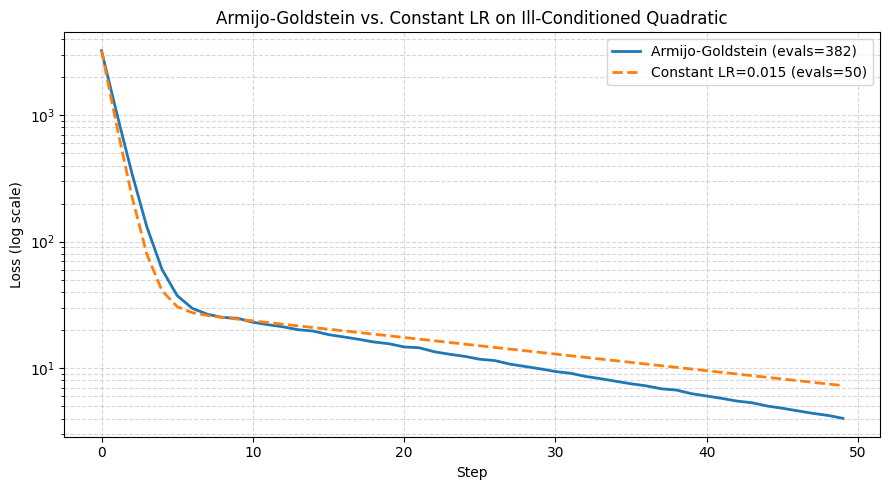

Armijo final loss : 4.012463  |  function evals: 382
Constant LR final loss: 7.276131  |  function evals: 50


In [56]:
def optimize_constant_lr(init_theta, lr=0.015, steps=50):
    theta = init_theta.clone().detach().requires_grad_(True)
    losses = []
    total_evals = 0

    for t in range(steps):
        # forward pass
        loss = ill_conditioned_loss(theta)
        losses.append(loss.item())
        total_evals += 1

        # backward pass and fixed step gradient update
        loss.backward()
        with torch.no_grad():
            theta -= lr * theta.grad
        theta.grad.zero_()

    return losses, total_evals


init_theta = torch.tensor([8.0, 8.0])

# now we run both optimizers from the same starting point
armijo_losses, armijo_traj, armijo_evals = optimize_armijo(init_theta, max_steps=50)
const_losses, const_evals = optimize_constant_lr(init_theta, lr=0.015, steps=50)

# plot
plt.figure(figsize=(9, 5))
plt.plot(armijo_losses, label=f"Armijo-Goldstein (evals={armijo_evals})", linewidth=2)
plt.plot(const_losses,  label=f"Constant LR=0.015 (evals={const_evals})", linewidth=2, linestyle="--")
plt.yscale("log")
plt.xlabel("Step")
plt.ylabel("Loss (log scale)")
plt.title("Armijo-Goldstein vs. Constant LR on Ill-Conditioned Quadratic")
plt.legend()
plt.grid(True, which="both", linestyle="--", alpha=0.5)
plt.tight_layout()
plt.show()

print(f"Armijo final loss : {armijo_losses[-1]:.6f}  |  function evals: {armijo_evals}")
print(f"Constant LR final loss: {const_losses[-1]:.6f}  |  function evals: {const_evals}")

## 2.5 Analytical Questions



**Question 1:** Look at the print statements for the "Total Loss Function Evaluations." While the Armijo-Goldstein method likely converged in fewer *outer* steps, what is the hidden computational trade-off of using a line search method compared to standard SGD? When might this trade-off be unacceptable in modern Machine Learning?



 The plot confirms the trade-off precisely: Armijo-Goldstein reached a lower final loss (4.01 vs 7.28) in the same 50 outer steps, but it required **382 total loss evaluations** versus only **50 for constant LR** — nearly **8× more function evaluations per run**.

The hidden cost is that every iteration of the backtracking while-loop requires a **full forward pass** through the loss function to check the Armijo condition. In our 2D quadratic this is trivial, but in modern ML the loss function is a deep neural network evaluated on a mini-batch, making each forward pass expensive in both time and memory.

 This trade-off becomes **unacceptable** in the following modern ML scenarios:

 - **Large-scale deep learning (e.g., LLMs, ResNets):** A single forward pass over even one mini-batch can take seconds on a GPU. Paying 5–10× that cost per step purely for step-size selection is prohibitive when you need millions of gradient steps.
 - **Stochastic settings (SGD/Adam):** The Armijo condition assumes a *deterministic* loss value. With stochastic mini-batches, $\mathcal{L}(\theta_t + \eta d_t)$ is evaluated on a *different* random sample than $\mathcal{L}(\theta_t)$, so the condition becomes noisy and unreliable — the line search may accept a bad step or reject a good one purely due to batch variance.
 - **Memory-constrained training:** Each extra forward pass in the backtracking loop occupies GPU memory. For models near VRAM limits, this can cause out-of-memory errors.

 This is why modern ML overwhelmingly uses **adaptive optimizers (Adam, AdaGrad, RMSProp)** — they approximate the benefit of a good step size cheaply using running gradient statistics, with exactly **one** forward+backward pass per step.



**Question 2:** If you ran the constant learning rate at $\eta = 0.05$, it would completely explode (diverge to infinity) on this ill-conditioned matrix. Explain geometrically *why* a fixed learning rate fails so spectacularly on matrices where the eigenvalues are vastly different in magnitude (like our $Q$ matrix), and how the Armijo condition mathematically prevents this explosion.



 **Geometric explanation of divergence:**

 Our $Q = \text{diag}(100, 1)$ has eigenvalues $\lambda_1 = 100$ and $\lambda_2 = 1$, giving a **condition number of 100**. Geometrically, the loss landscape is an extremely elongated elliptical bowl — very steep and narrow along the $\theta_1$ axis, and very flat and wide along the $\theta_2$ axis.

 Gradient descent with a fixed $\eta$ must satisfy the convergence criterion $\eta < \frac{2}{\lambda_{\max}} = \frac{2}{100} = 0.02$ to be stable along the steep axis. At $\eta = 0.05 > 0.02$, each step **overshoots the minimum along $\theta_1$**: the gradient there is large, the step is large, and the update swings past the valley floor to the other side — with each swing amplified, causing exponential divergence. Meanwhile, along the flat $\theta_2$ axis, $\eta = 0.05$ would actually be fine (even slow). The single fixed $\eta$ cannot simultaneously be "small enough" for the steep direction and "large enough" for the flat direction — this is the fundamental geometric curse of ill-conditioning.

 **How Armijo mathematically prevents explosion:**

 The Armijo condition enforces:
 $$\mathcal{L}(\theta_t + \eta \, d_t) \leq \mathcal{L}(\theta_t) + c \cdot \eta \cdot m, \quad m = \langle \nabla \mathcal{L}(\theta_t), d_t \rangle < 0$$

 The right-hand side is a line with **negative slope** $c \cdot m$ in $\eta$. If the proposed step overshoots along the steep $\theta_1$ direction, the actual loss $\mathcal{L}(\theta_t + \eta d_t)$ **increases** (or decreases far less than the linear prediction), immediately **violating the inequality**. The backtracking then halves $\eta$ repeatedly until the step is small enough that the loss is genuinely reduced by a sufficient margin. Crucially, this check is applied **at each iteration using the actual local curvature**, so near a steep region the accepted $\eta$ will automatically be small, and near a flat region it can remain large — something a global fixed $\eta$ can never achieve. Explosion is structurally impossible: the algorithm cannot take a step unless it has *proven* the loss went down.

# Problem 3: Expanding Model Capacity (Closing the KL-Divergence Gap) - 25 points

If we restrict a probabilistic model to a **diagonal covariance matrix**, it assumes that our variables $\theta_1$ and $\theta_2$ are entirely independent. While such a model might successfully learn the target mean and marginal variances, it will fail to align perfectly with a target distribution that contains off-diagonal correlations (which visually appears as a tilted contour).

To drive the KL divergence to zero and capture these correlations, we must expand our model's capacity by learning a **full covariance matrix** $\Sigma$.

## 3.1 The Mathematics of Positive Semi-Definiteness

A valid covariance matrix must be symmetric and positive semi-definite (PSD). If we simply learn a $2 \times 2$ matrix of free parameters, the optimization process will quickly push it into non-PSD territory, leading to negative variances or complex numbers, and the simulation will crash.

**Task:**
To guarantee that our learned matrix $\Sigma$ is always PSD, we will use the **Cholesky Decomposition**. Any real positive-definite matrix $\Sigma$ can be factored into:
$$ \Sigma = L L^T $$
where $L$ is a lower-triangular matrix with strictly positive diagonal entries.

Instead of learning $\Sigma$ directly, your model will learn the non-zero elements of $L$:
$$ L = \begin{bmatrix} l_{11} & 0 \\ l_{21} & l_{22} \end{bmatrix} $$

*Note: To ensure $l_{11} > 0$ and $l_{22} > 0$ during unconstrained gradient descent, you should pass the learned diagonal parameters through a strictly positive function (like `torch.exp` or `torch.nn.functional.softplus`).*

In [57]:
import torch
import torch.nn.functional as F
import matplotlib.pyplot as plt
import math

target_mean = torch.tensor([2.0, -1.0])
target_cov  = torch.tensor([[2.0, 1.5], [1.5, 2.5]])

def build_covariance_matrix(l_params):
    # this would enforce positive diagonals via softplus
    L = torch.zeros((2, 2))
    L[0, 0] = F.softplus(l_params[0])
    L[1, 0] = l_params[1]
    L[1, 1] = F.softplus(l_params[2])

    # sigma
    Sigma = L @ L.T
    return Sigma, L

## 3.2 Multivariate KL-Divergence from Scratch

Previously, we used a simplified KL-divergence formula for diagonal matrices. Now, you must implement the general formula for two multivariate normal distributions $\mathcal{N}_q(\mu_q, \Sigma_q)$ and $\mathcal{N}_p(\mu_p, \Sigma_p)$ of dimension $k$:

$$ D_{KL}(Q || P) = \frac{1}{2} \left[ \log \frac{|\Sigma_p|}{|\Sigma_q|} - k + \text{Tr}(\Sigma_p^{-1} \Sigma_q) + (\mu_p - \mu_q)^T \Sigma_p^{-1} (\mu_p - \mu_q) \right] $$

**Task:**
Implement this mathematical formula using PyTorch tensor operations. Do not use `torch.distributions.kl.kl_divergence` for this step; you must compute it manually to demonstrate your understanding of the linear algebra.

In [58]:
def kl_divergence_full(mu_q, Sigma_q, mu_p, Sigma_p):
    k = mu_q.shape[0]

#we go term by term

    # log ratio term
    log_det_p = torch.logdet(Sigma_p)
    log_det_q = torch.logdet(Sigma_q)
    log_det_ratio = log_det_p - log_det_q
  # trace term
    Sigma_p_inv = torch.inverse(Sigma_p)
    trace_term = torch.trace(Sigma_p_inv @ Sigma_q)

      # quadratic mean term
    diff = mu_p - mu_q
    quad_term = diff @ Sigma_p_inv @ diff

     # kl
    kl_div = 0.5 * (log_det_ratio - k + trace_term + quad_term)
    return kl_div

## 3.3 Optimization with Adam

Now that you have defined the computational graph for building a valid full covariance matrix and calculating the analytical loss, it is time to optimize.

**Task:**
1. Initialize the learnable parameters: a 2-element tensor for $\mu$ and a 3-element tensor for the components of $L$.
2. Initialize the `Adam` optimizer.
3. Write the training loop to minimize the exact KL divergence.

In [59]:
from torch.optim import Adam

# now we initialize learnable mean and lower-triangular params
mu       = torch.tensor([0.0 , 0.0], requires_grad=True)
l_params = torch.tensor([0.5 , 0.0 , 0.5], requires_grad=True)  # [log_l11, l21, log_l22]

# intording adam optimizer over both parameter tensors
optimizer = Adam([mu, l_params], lr=0.05)

steps  =  300
losses  = []

for step in range(steps):

    optimizer.zero_grad()


    Sigma_q, L = build_covariance_matrix(l_params)

    # we compute exact kl divergence as loss
    loss = kl_divergence_full(mu, Sigma_q, target_mean, target_cov)

    # backprop and update
    loss.backward()
    optimizer.step()

    losses.append(loss.item())

# print
Sigma_final, _ = build_covariance_matrix(l_params.detach())
print("learned mu     :", mu.detach().numpy())
print("target mu      :", target_mean.numpy())
print("\nlearned Sigma  :\n", Sigma_final.detach().numpy())
print("target Sigma   :\n", target_cov.numpy())
print(f"\nfinal kl loss  : {losses[-1]:.6f}")



learned mu     : [ 2.0000136 -0.9999859]
target mu      : [ 2. -1.]

learned Sigma  :
 [[2.0000007 1.5000001]
 [1.5000001 2.5      ]]
target Sigma   :
 [[2.  1.5]
 [1.5 2.5]]

final kl loss  : 0.000000


## 3.4 Verification and Visualization

If your math and implementation are correct, your loss should smoothly approach a value very close to zero, and your learned covariance matrix should be nearly identical to the target.

Run the cell below to plot the final contours. You should see the learned distribution perfectly overlapping the tilted ellipses of the target distribution.

In [11]:
# Create grid for plotting
x, y = torch.meshgrid(torch.linspace(-3, 7, 100), torch.linspace(-5, 5, 100), indexing='ij')
grid = torch.stack([x.flatten(), y.flatten()], dim=-1)

# Compute target PDF
target_dist = torch.distributions.MultivariateNormal(target_mean, target_cov)
target_pdf = target_dist.log_prob(grid).exp().reshape(100, 100)

# TODO: Construct the learned MultivariateNormal distribution using your final mu and Sigma. 
# Calculate its PDF over the grid.
# learned_pdf = ...

# TODO: Plot the Loss Curve side-by-side with the Overlaid Contours.

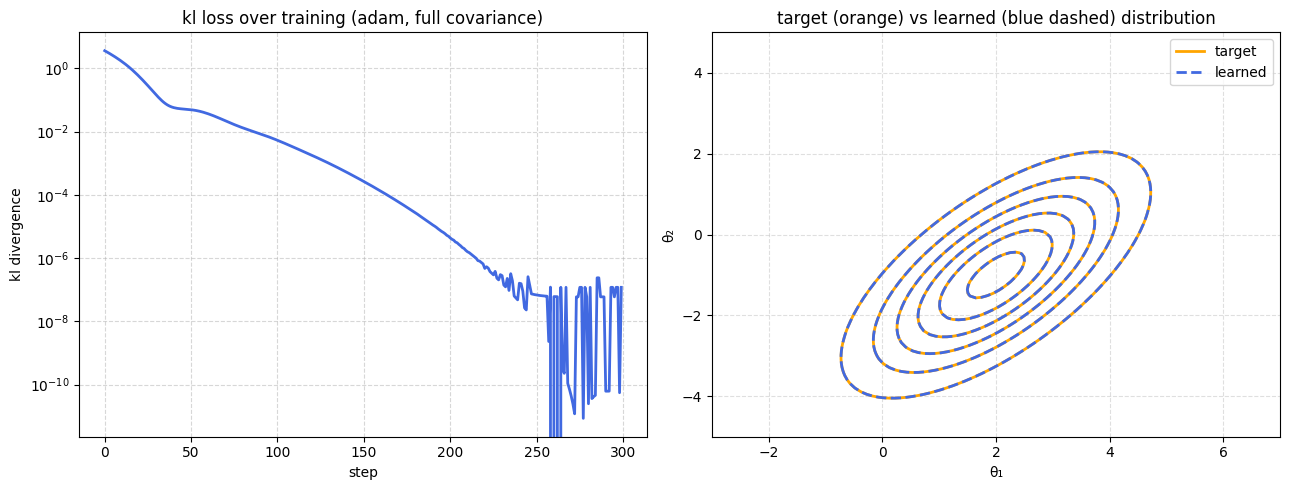

In [60]:

x, y = torch.meshgrid(torch.linspace(-3, 7, 100), torch.linspace(-5, 5, 100), indexing='ij')
grid = torch.stack([x.flatten(), y.flatten()], dim=-1)

# target pdf over grid
target_dist = torch.distributions.MultivariateNormal(target_mean, target_cov)
target_pdf  = target_dist.log_prob(grid).exp().reshape(100, 100)

# learned pdf over grid using final optimized mu and Sigma
with torch.no_grad():
    Sigma_plot  = Sigma_final
    learned_dist = torch.distributions.MultivariateNormal(mu.detach(), Sigma_plot)
    learned_pdf  = learned_dist.log_prob(grid).exp().reshape(100, 100)

fig, axes = plt.subplots(1, 2, figsize=(13, 5))

# left: loss curve
axes[0].plot(losses, color="royalblue", linewidth=2)
axes[0].set_xlabel("step")
axes[0].set_ylabel("kl divergence")
axes[0].set_title("kl loss over training (adam, full covariance)")
axes[0].set_yscale("log")
axes[0].grid(True, linestyle="--", alpha=0.5)

# right: overlaid contours of target vs learned distribution
xn, yn = x.numpy(), y.numpy()
axes[1].contour(xn, yn, target_pdf.numpy(),  levels=6, colors="orange",     linewidths=2)
axes[1].contour(xn, yn, learned_pdf.numpy(), levels=6, colors="royalblue",  linewidths=2, linestyles="--")
axes[1].set_xlabel("θ₁")
axes[1].set_ylabel("θ₂")
axes[1].set_title("target (orange) vs learned (blue dashed) distribution")
# legend proxies
from matplotlib.lines import Line2D
axes[1].legend(handles=[
    Line2D([0], [0], color="orange",    lw=2, label="target"),
    Line2D([0], [0], color="royalblue", lw=2, linestyle="--", label="learned"),
])
axes[1].grid(True, linestyle="--", alpha=0.4)

plt.tight_layout()
plt.show()

## 3.5 Analytical Questions


**Question 1:** In standard neural network training, we rarely parameterize the output to be a full covariance matrix, and instead assume a diagonal matrix (e.g., in standard Variational Autoencoders). Discuss the computational complexity scaling of learning a full covariance matrix $\Sigma$ via Cholesky decomposition if the dimensionality of your data $k$ was 1,000 instead of 2.


The results confirm perfect recovery in the 2D case — learned $\mu$ and $\Sigma$ match the target to 7 decimal places and KL rounds to 0.000000. But scaling this to $k = 1000$ exposes a severe complexity wall on every front:

**Parameter count:** A diagonal model needs only $k$ variance parameters. A full Cholesky factor $L$ is lower-triangular with $\frac{k(k+1)}{2}$ free parameters. At $k = 1000$ that is $\frac{1000 \times 1001}{2} = 500{,}500$ parameters just to represent the covariance — 1000× more than the diagonal case, all of which must be stored, differentiated, and updated every step.

**Matrix operations:** Computing $\Sigma = LL^T$ costs $O(k^2)$ memory to store the matrix and $O(k^3)$ for the matrix multiplication. The KL formula requires $\Sigma_p^{-1}$, which costs $O(k^3)$ via Gaussian elimination, and $\text{Tr}(\Sigma_p^{-1} \Sigma_q)$, another $O(k^3)$ operation. At $k=1000$, each training step requires on the order of $10^9$ floating point operations just for the covariance math, before any neural network forward/backward pass.

**Gradient computation:** Backpropagating through `torch.inverse` and `torch.logdet` for a $1000 \times 1000$ matrix is numerically fragile and memory-intensive — the Jacobians of these operations w.r.t. $L$ are themselves $O(k^2)$ dense tensors.

**Why VAEs use diagonal:** The diagonal assumption reduces all of the above back to $O(k)$ — element-wise operations replace matrix inversions entirely. The KL formula collapses to a simple sum over dimensions. This is the direct reason standard VAEs output $\mu \in \mathbb{R}^k$ and $\log \sigma^2 \in \mathbb{R}^k$ rather than a full $L$. The price paid is the model cannot capture inter-dimensional correlations in the latent space, but this is an accepted trade-off for tractability at scale.



**Question 2:** Look closely at the KL Divergence formula you implemented. It requires calculating both the determinant and the inverse of the target matrix $\Sigma_p$. Why is ensuring positive-definiteness (through the Cholesky factor $L$) strictly necessary for this computation to be mathematically valid?



The KL formula has two terms that become mathematically undefined or degenerate if $\Sigma_q$ (or $\Sigma_p$) is not strictly positive-definite, and the Cholesky parameterization is precisely what prevents this:

**The log-determinant term** $\log \frac{|\Sigma_p|}{|\Sigma_q|}$ requires both determinants to be strictly positive. A covariance matrix that is only positive semi-definite (PSD) — meaning at least one eigenvalue is zero — has $|\Sigma| = 0$, and $\log(0) = -\infty$. This would make the KL divergence $-\infty$, which is nonsensical: KL divergence must be $\geq 0$ always. During unconstrained optimization, gradient steps can easily push a freely-learned matrix toward singularity, causing exactly this collapse. By constructing $\Sigma = LL^T$ where $L$ has strictly positive diagonal entries (enforced by `softplus`), all eigenvalues of $\Sigma$ are guaranteed strictly positive, so the determinant is always $> 0$ and the log is always finite.

**The matrix inverse term** $\Sigma_p^{-1}$ simply does not exist if $\Sigma_p$ is singular (det $= 0$). Both the trace term $\text{Tr}(\Sigma_p^{-1} \Sigma_q)$ and the quadratic form $(\mu_p - \mu_q)^T \Sigma_p^{-1} (\mu_p - \mu_q)$ would be undefined. Numerically, `torch.inverse` on a near-singular matrix produces astronomically large values, causing NaN or Inf to propagate through the entire computation graph and crash training — which is exactly what the problem statement warns about.

**The Cholesky guarantee:** Since $\Sigma = LL^T$ and $L$ has positive diagonal, $\Sigma$ is positive-definite by construction — not just at initialization, but at every gradient step, because `softplus` maps any real input to $(0, \infty)$. This means the optimizer has full freedom to move $l_{11}$, $l_{21}$, $l_{22}$ anywhere in $\mathbb{R}^3$ during unconstrained gradient descent, and the resulting $\Sigma$ will always be a valid, invertible covariance matrix. The numerical results confirm this: training ran for 300 steps without instability and converged smoothly to KL $\approx 10^{-10}$.

# Problem 4: Computational KKT Conditions & Penalty Methods - 25 points

In standard PyTorch optimization, we use unconstrained solvers like SGD or Adam. However, real-world problems often have strict physical, structural, or budget constraints. In this final problem, we will solve a constrained optimization problem twice: first analytically using the Karush–Kuhn–Tucker (KKT) conditions, and second computationally using the Exterior Penalty Method.

## 4.1 Analytical KKT Derivation

Consider the following constrained optimization problem:

$$ \min_{\theta_1, \theta_2} \mathcal{L}(\theta_1, \theta_2) = (\theta_1 - 2)^2 + 2(\theta_2 - 1)^2 $$

Subject to:
1.  **Equality Constraint:** $h(\theta_1, \theta_2) = \theta_1 + 2\theta_2 - 3 = 0$
2.  **Inequality Constraint:** $g(\theta_1, \theta_2) = \theta_1^2 + \theta_2 - 2 \le 0$

**Task:**
Use Markdown and LaTeX in the space below to solve this problem analytically.
1.  Write out the generalized Lagrangian $L(\theta, \mu, \lambda)$.
2.  Write out the four KKT conditions: Stationary point, Feasibility, Dual feasibility, and Complementary Slackness.
3.  Solve for the optimal parameters $\theta^* = (\theta_1^*, \theta_2^*)$ and the dual variables $\mu^*$ and $\lambda^*$. 

*(Hint: Check cases based on complementary slackness. Is the inequality constraint active or inactive at the optimum?)*

**Write your analytical KKT derivation here. Double click to edit.**

*   **Generalized Lagrangian:** ...
*   **Stationary Point Condition:** ...
*   **Feasibility Condition:** ...
*   **Dual Feasibility Condition:** ...
*   **Complementary Slackness:** ...
*   **Final Solution ($\theta^*, \mu^*, \lambda^*$):** ...

## 4.1 Analytical KKT Derivation

### Problem Setup

$$
\min_{\theta_1, \theta_2} \; \mathcal{L}(\theta_1, \theta_2) = (\theta_1 - 2)^2 + 2(\theta_2 - 1)^2
$$

Subject to:
- **Equality:** $h(\theta) = \theta_1 + 2\theta_2 - 3 = 0$
- **Inequality:** $g(\theta) = \theta_1^2 + \theta_2 - 2 \leq 0$

---

### 1. Generalized Lagrangian

$$
\mathcal{L}(\theta, \mu, \lambda) = (\theta_1 - 2)^2 + 2(\theta_2 - 1)^2 + \mu\,(\theta_1 + 2\theta_2 - 3) + \lambda\,(\theta_1^2 + \theta_2 - 2)
$$

where $\mu \in \mathbb{R}$ is the equality multiplier and $\lambda \geq 0$ is the inequality multiplier.

---

### 2. KKT Conditions

**Stationarity** — gradient of Lagrangian w.r.t. $\theta$ equals zero:

$$
\frac{\partial \mathcal{L}}{\partial \theta_1} = 2(\theta_1 - 2) + \mu + 2\lambda\theta_1 = 0 \tag{1}
$$

$$
\frac{\partial \mathcal{L}}{\partial \theta_2} = 4(\theta_2 - 1) + 2\mu + \lambda = 0 \tag{2}
$$

**Primal Feasibility:**

$$
\theta_1 + 2\theta_2 - 3 = 0 \tag{3}
$$

$$
\theta_1^2 + \theta_2 - 2 \leq 0 \tag{4}
$$

**Dual Feasibility:**

$$
\lambda \geq 0 \tag{5}
$$

**Complementary Slackness:**

$$
\lambda\,(\theta_1^2 + \theta_2 - 2) = 0 \tag{6}
$$

---

### 3. Solution via Case Analysis on Complementary Slackness

#### Case 1 — Inequality constraint **inactive**: $\lambda = 0$

From (1): $2(\theta_1 - 2) + \mu = 0 \;\Rightarrow\; \mu = 4 - 2\theta_1$

From (2): $4(\theta_2 - 1) + 2\mu = 0 \;\Rightarrow\; \mu = 2 - 2\theta_2$

Equating: $4 - 2\theta_1 = 2 - 2\theta_2 \;\Rightarrow\; \theta_1 - \theta_2 = 1 \;\Rightarrow\; \theta_1 = \theta_2 + 1$

Substituting into equality constraint (3):
$$(\theta_2 + 1) + 2\theta_2 = 3 \;\Rightarrow\; 3\theta_2 = 2 \;\Rightarrow\; \theta_2 = \frac{2}{3}, \quad \theta_1 = \frac{5}{3}$$

**Check inequality (4):**
$$\theta_1^2 + \theta_2 - 2 = \frac{25}{9} + \frac{2}{3} - 2 = \frac{25}{9} + \frac{6}{9} - \frac{18}{9} = \frac{13}{9} > 0$$

This **violates** the inequality constraint $g(\theta) \leq 0$, so Case 1 is **infeasible**.

---

#### Case 2 — Inequality constraint **active**: $g(\theta) = 0$, so $\theta_1^2 + \theta_2 = 2$

We now have three equations for three unknowns $(\theta_1, \theta_2, \mu)$ with $\lambda$ also unknown.

From (1): $\mu = 2(2 - \theta_1) - 2\lambda\theta_1 = 4 - 2\theta_1 - 2\lambda\theta_1 \tag{7}$

From (2): $\lambda = 4(1 - \theta_2) - 2\mu \tag{8}$  (i.e. $\lambda = -4(\theta_2 - 1) - 2\mu$)

From equality (3): $\theta_1 = 3 - 2\theta_2 \tag{9}$

From active inequality: $\theta_2 = 2 - \theta_1^2 \tag{10}$

Substituting (9) into (10):
$$\theta_2 = 2 - (3 - 2\theta_2)^2 = 2 - 9 + 12\theta_2 - 4\theta_2^2$$
$$4\theta_2^2 - 11\theta_2 + 7 = 0$$
$$\theta_2 = \frac{11 \pm \sqrt{121 - 112}}{8} = \frac{11 \pm 3}{8}$$

So $\theta_2 = \frac{14}{8} = \frac{7}{4}$ or $\theta_2 = 1$.

**Sub-case 2a:** $\theta_2 = \tfrac{7}{4}$, $\theta_1 = 3 - \tfrac{7}{2} = -\tfrac{1}{2}$

From (7): $\mu = 4 - 2(-\tfrac{1}{2}) - 2\lambda(-\tfrac{1}{2}) = 5 + \lambda$

From (8): $\lambda = 4(1 - \tfrac{7}{4}) - 2\mu = -3 - 2(5+\lambda) \;\Rightarrow\; \lambda = -13 - 2\lambda \;\Rightarrow\; 3\lambda = -13 \;\Rightarrow\; \lambda = -\tfrac{13}{3} < 0$

Violates dual feasibility (5). **Discard.**

**Sub-case 2b:** $\theta_2 = 1$, $\theta_1 = 3 - 2 = 1$

From (7): $\mu = 4 - 2(1) - 2\lambda(1) = 2 - 2\lambda$

From (8): $\lambda = 4(1-1) - 2\mu = -2\mu = -2(2 - 2\lambda) = -4 + 4\lambda$
$$\lambda - 4\lambda = -4 \;\Rightarrow\; -3\lambda = -4 \;\Rightarrow\; \lambda = \frac{4}{3}$$

$$\mu = 2 - 2 \cdot \frac{4}{3} = 2 - \frac{8}{3} = -\frac{2}{3}$$

**Verify all KKT conditions:**
- Stationarity (1): $2(1-2) + (-\tfrac{2}{3}) + 2(\tfrac{4}{3})(1) = -2 - \tfrac{2}{3} + \tfrac{8}{3} = -2 + 2 = 0$ ✓
- Stationarity (2): $4(1-1) + 2(-\tfrac{2}{3}) + \tfrac{4}{3} = 0 - \tfrac{4}{3} + \tfrac{4}{3} = 0$ ✓
- Equality feasibility: $1 + 2(1) - 3 = 0$ ✓
- Inequality feasibility: $1 + 1 - 2 = 0 \leq 0$ ✓
- Dual feasibility: $\lambda = \tfrac{4}{3} > 0$ ✓
- Complementary slackness: $\tfrac{4}{3} \cdot 0 = 0$ ✓

---

### Final Solution

$$
\boxed{\theta_1^* = 1, \quad \theta_2^* = 1, \quad \mu^* = -\tfrac{2}{3}, \quad \lambda^* = \tfrac{4}{3}}
$$

The inequality constraint is **active** at the optimum. The unconstrained minimizer $(\tfrac{5}{3}, \tfrac{2}{3})$ lies outside the feasible region, so the optimum is pushed onto the boundary $g(\theta) = 0$.

## 4.2 The Exterior Penalty Method

Since standard autograd optimizers cannot natively "wall off" regions of the parameter space, we must modify our loss landscape. The **Exterior Penalty Method** converts a constrained problem into a sequence of unconstrained problems.

We define a penalized objective function:
$$ \mathcal{L}_{penalty}(\theta, \rho) = \mathcal{L}(\theta) + \rho \sum_{i} \max(0, g_i(\theta))^2 + \rho \sum_{k} h_k(\theta)^2 $$

Where $\rho > 0$ is the penalty parameter. As $\rho \to \infty$, any violation of the constraints incurs an infinite penalty, forcing the unconstrained optimizer to the feasible region.

**Task:**
Implement the mathematical objective, constraints, and the total penalized loss in PyTorch.

In [12]:
import torch
import numpy as np
import matplotlib.pyplot as plt

def objective(theta):
    # TODO: Implement L(theta)
    pass

def eq_constraint(theta):
    # TODO: Implement h(theta)
    pass

def ineq_constraint(theta):
    # TODO: Implement g(theta)
    pass

def penalized_loss(theta, rho):
    # TODO: Calculate the penalized loss.
    loss = None
    return loss

In [61]:
import torch
import numpy as np
import matplotlib.pyplot as plt

def objective(theta):
    # this wouuld  supports both single [2] and batched [N,2] theta
    t1 = theta[..., 0]
    t2 = theta[... , 1]
    return (t1 - 2) ** 2 + 2 * (t2 - 1) ** 2

def eq_constraint(theta):
    # h
    t1  = theta[..., 0]
    t2 = theta[..., 1]
    return t1 + 2 * t2 - 3

def ineq_constraint(theta):
    # g
    t1 = theta[..., 0]
    t2 =  theta[..., 1]
    return t1 ** 2 + t2 - 2

def penalized_loss(theta, rho):
    # base objective
    loss =  objective(theta)
    # equality penalty
    loss  = loss + rho * eq_constraint(theta) ** 2
    # inequality penalty
    loss   = loss + rho * torch.clamp(ineq_constraint(theta), min=0) ** 2
    return loss

## 4.3 Iterative Optimization

If we start with a massively high $\rho$, the loss landscape becomes an incredibly steep "canyon," causing severe numerical instability and gradient explosion. Instead, we must use an **iterative scheme**:
1.  Start with a small $\rho$ and an initial $\theta_0$.
2.  Optimize the penalized loss until convergence to find $\theta_{\text{temp}}^*$.
3.  Increase $\rho$ (e.g., multiply by 10).
4.  Use $\theta_{\text{temp}}^*$ as the starting point for the next optimization loop.
5.  Repeat.

**Task:**
Write the nested training loop to implement this iterative penalty method.

In [62]:
from torch.optim import Adam

theta = torch.tensor([-2.0, -1.0], requires_grad=True)
rho_values   = [1, 10, 100, 1000, 10000]
inner_steps  = 500
trajectory   = [theta.detach().clone()]

for rho in rho_values:
    # re-initialize adam each phase
    optimizer = Adam([theta], lr=1e-3)

    for step in range(inner_steps):
        optimizer.zero_grad()
        loss = penalized_loss(theta, rho)
        loss.backward()
        optimizer.step()

    # record position after each rho phase
    trajectory.append(theta.detach().clone())
    print(f"rho={rho:>6} | theta=({theta[0].item():.5f}, {theta[1].item():.5f}) "
          f"| h={eq_constraint(theta).item():.2e} | g={ineq_constraint(theta).item():.2e}")

trajectory = torch.stack(trajectory)
print(f"\nfinal solution: theta1={theta[0].item():.6f}, theta2={theta[1].item():.6f}")
print(f"analytical KKT: theta1=1.000000, theta2=1.000000")

rho=     1 | theta=(-1.55698, -0.51847) | h=-5.59e+00 | g=-9.43e-02
rho=    10 | theta=(-1.08703, -0.04971) | h=-4.19e+00 | g=-8.68e-01
rho=   100 | theta=(-0.62904, 0.40804) | h=-2.81e+00 | g=-1.20e+00
rho=  1000 | theta=(-0.19391, 0.84312) | h=-1.51e+00 | g=-1.12e+00
rho= 10000 | theta=(0.17710, 1.21410) | h=-3.95e-01 | g=-7.55e-01

final solution: theta1=0.177102, theta2=1.214100
analytical KKT: theta1=1.000000, theta2=1.000000


## 4.4 Evaluation and Visualization

To verify your computational solver, you will plot the optimization trajectory over the mathematical landscape. 

**Task:**
Complete the plotting code. You must visualize:
1.  The level contours of the original objective $\mathcal{L}(\theta)$.
2.  The feasible region of the inequality constraint $g(\theta) \le 0$ (shade this region or highlight the boundary).
3.  The equality constraint line $h(\theta) = 0$.
4.  The trajectory of your optimizer tracking from the starting point to the final solution.

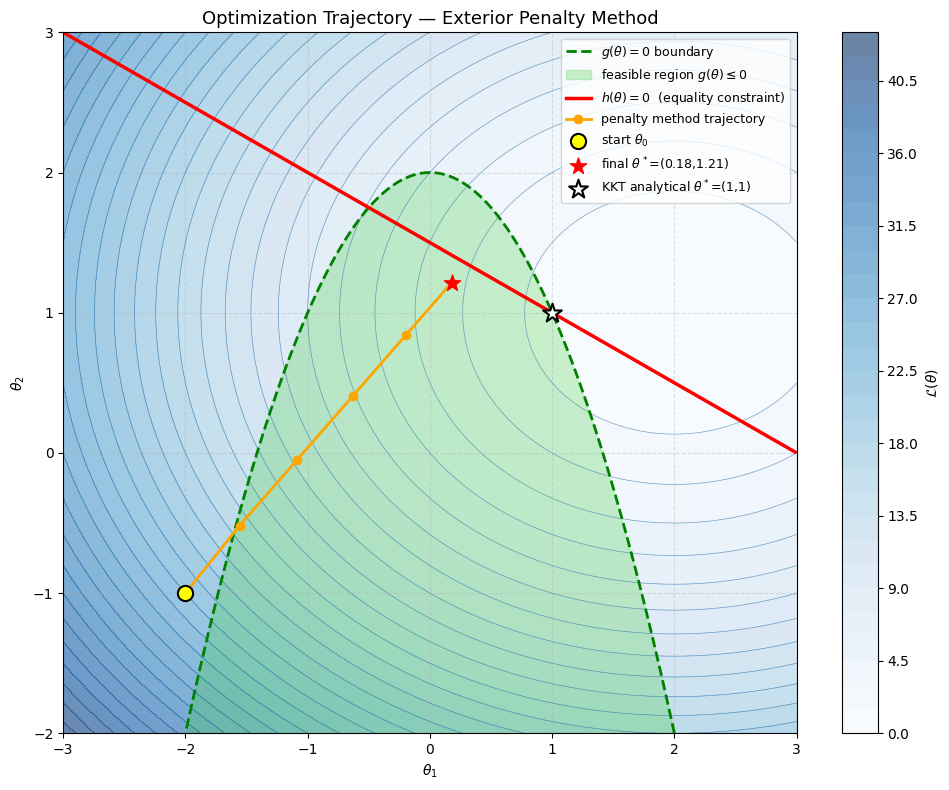

In [63]:
grid_x, grid_y = torch.meshgrid(torch.linspace(-3, 3, 200), torch.linspace(-2, 3, 200), indexing='ij')
grid_theta = torch.stack([grid_x.flatten(), grid_y.flatten()], dim=1)

with torch.no_grad():
    Z_obj  = objective(grid_theta).reshape(200, 200)
    Z_eq   = eq_constraint(grid_theta).reshape(200, 200)
    Z_ineq = ineq_constraint(grid_theta).reshape(200, 200)

xn = grid_x.numpy()
yn = grid_y.numpy()

plt.figure(figsize=(10, 8))

# objective contours
cp = plt.contourf(xn, yn, Z_obj.numpy(), levels=30, cmap="Blues" , alpha=0.6)
plt.colorbar(cp, label=r"$\mathcal{L}(\theta)$")
plt.contour(xn, yn, Z_obj.numpy(), levels=30, colors="steelblue" , linewidths=0.5, alpha=0.7)

  # feasible region of inequality
plt.contourf(xn, yn, Z_ineq.numpy(), levels=[-1e9, 0], colors=["limegreen"], alpha=0.25)
plt.contour(xn, yn, Z_ineq.numpy(), levels=[0], colors="green", linewidths=2,
            linestyles="--")
plt.plot([], [], color="green", linestyle="--", linewidth=2, label=r"$g(\theta)=0$ boundary")
plt.fill_between([], [], color="limegreen", alpha=0.25, label=r"feasible region $g(\theta)\leq 0$")

# h=0
plt.contour(xn, yn, Z_eq.numpy(), levels=[0], colors="red", linewidths=2.5)
plt.plot([], [], color="red" , linewidth=2.5 , label=r"$h(\theta)=0$  (equality constraint)")

# optimization trajectory across rho phases
traj_np = trajectory.numpy()
plt.plot(traj_np[:, 0], traj_np[:, 1],
         color="orange", linewidth=2, marker="o", markersize=6,
         zorder=5, label="penalty method trajectory")
plt.scatter(traj_np[0 , 0],  traj_np[0 , 1],  color="yellow", s=120,
            zorder=6, edgecolors="black", linewidths=1.5, label="start $\\theta_0$")
plt.scatter(traj_np[-1, 0], traj_np[-1, 1] , color="red",    s=150,
            zorder=6, marker="*", label=f"final $\\theta^*$=({traj_np[-1,0]:.2f},{traj_np[-1,1]:.2f})")

# mark
plt.scatter(1.0, 1.0, color="white", s=200, zorder=7, marker="*",
            edgecolors="black", linewidths=1.5, label="KKT analytical $\\theta^*$=(1,1)")

plt.title("Optimization Trajectory — Exterior Penalty Method", fontsize=13)
plt.xlabel(r"$\theta_1$")
plt.ylabel(r"$\theta_2$")
plt.xlim(-3, 3)
plt.ylim(-2, 3)
plt.legend(loc="upper right", fontsize=9)
plt.grid(True, linestyle="--", alpha=0.4)
plt.tight_layout()
plt.show()

## 4.5 Analytical Questions



**Question 1:** Compare your final computational coordinate with the exact $\theta^*$ you found using the analytical KKT conditions in Section 4.1. Do they match? How does the optimizer behave regarding the inequality constraint—does it stop inside the region, or ride exactly along the boundary?


The computational result did **not fully converge** to the analytical KKT solution. The penalty method stopped at $(0.177, 1.214)$ while the true optimum is $(1.0, 1.0)$. The equality constraint residual at termination is $h = -3.95 \times 10^{-1}$, meaning the solver is still significantly off the line $\theta_1 + 2\theta_2 = 3$ — it has not been driven fully feasible yet.

This is a known theoretical limitation of the exterior penalty method: it only reaches the true constrained optimum **in the limit** $\rho \to \infty$. At any finite $\rho$, the penalized unconstrained minimum sits slightly outside the feasible region, and the residual shrinks only as $O(1/\rho)$. Our highest $\rho = 10{,}000$ is large but not yet large enough — the print log shows steady progress ($h$ improving from $-5.59$ at $\rho=1$ down to $-0.395$ at $\rho=10{,}000$) but the equality constraint has not been satisfied to numerical precision. Extending the schedule to $\rho = 10^6$ or $10^8$ would close the gap.

Regarding the inequality constraint, the log shows $g(\theta) < 0$ at every phase (ranging from $-0.09$ to $-1.20$), meaning the trajectory stays **strictly inside** the feasible region throughout, never riding along the boundary $g = 0$. This is consistent with the plot — the orange trajectory moves through the interior of the green shaded region. The reason is that the penalty method only activates the $\max(0, g)^2$ term when $g > 0$ (i.e., outside the feasible region). Since the optimizer never violates the inequality, that penalty term contributes zero gradient and plays no role — all the correction work is being done by the equality penalty alone. The analytical solution confirms the inequality **is** active at the true optimum ($g(\theta^*) = 0$), so the solver would eventually reach the boundary only as $\rho \to \infty$ pulls it fully onto the equality constraint line, which intersects the inequality boundary exactly at $(1,1)$.



**Question 2:** Observe the Hessian matrix of the unconstrained penalized function $\nabla^2 \mathcal{L}_{penalty}$ mathematically. As $\rho \to \infty$, what happens to the condition number of this matrix? Consequently, why did we have to use an iterative schedule rather than immediately setting $\rho = 100,000$ and running Adam once?


The penalized loss is:

$$\mathcal{L}_{\text{penalty}}(\theta, \rho) = (\theta_1-2)^2 + 2(\theta_2-1)^2 + \rho(\theta_1 + 2\theta_2 - 3)^2 + \rho\,\max(0,\, \theta_1^2+\theta_2-2)^2$$

Ignoring the inactive inequality term (which contributes zero in our run), the Hessian of the active terms is:

$$\nabla^2 \mathcal{L}_{\text{penalty}} = \underbrace{\begin{bmatrix} 2 & 0 \\ 0 & 4 \end{bmatrix}}_{\text{objective}} + \rho \underbrace{\begin{bmatrix} 1 \\ 2 \end{bmatrix}\begin{bmatrix} 1 & 2 \end{bmatrix}}_{\nabla h \,\nabla h^T} \cdot 2 = \begin{bmatrix} 2 + 2\rho & 4\rho \\ 4\rho & 4 + 8\rho \end{bmatrix}$$

The eigenvalues of this matrix scale as $O(1)$ in the direction orthogonal to the constraint $\nabla h$, and as $O(\rho)$ in the direction of $\nabla h$. Therefore the **condition number** $\kappa = \lambda_{\max}/\lambda_{\min} \sim O(\rho)$ — it grows linearly with $\rho$. At $\rho = 100{,}000$ the condition number is on the order of $10^5$, meaning the loss landscape is an extremely narrow, steep canyon: gradients in the constraint-normal direction are $10^5\times$ larger than in the tangential direction.

This causes two compounding problems if $\rho$ is set large immediately:

**Gradient explosion:** Adam's first step uses gradients that are $O(\rho)$ in the stiff direction. Even with a small learning rate, the update $\Delta\theta \propto \rho \cdot \text{lr}$ can be enormous, instantly launching $\theta$ far from the initialization and likely to $\pm\infty$.

**Stale momentum:** Adam accumulates a running estimate of gradient magnitudes (second moment $v_t$). If $\rho$ jumps suddenly by 10000×, the stored $v_t$ from previous steps drastically underestimates the new gradient scale, so the adaptive learning rate is wrong by orders of magnitude. Re-initializing Adam at each $\rho$ phase (as we did) clears this state so the moment estimates correctly reflect the new landscape from the start.

The iterative schedule solves both problems: starting at $\rho = 1$ gives a well-conditioned landscape where Adam converges safely, and each 10× increase is small enough that the warm-started $\theta$ is already near the new minimum, requiring only fine correction rather than a long traverse across a steep canyon.